In [12]:
import sys
sys.path.append("..")

from src.data_loader import fetch_data, save_processed
from src.eda import add_returns_and_volatility, get_outliers, adf_test, risk_metrics

In [13]:
tickers = ["TSLA", "BND", "SPY"]
data = fetch_data(tickers, "2015-01-01", "2026-06-30")

tsla = add_returns_and_volatility(data["TSLA"])
bnd = add_returns_and_volatility(data["BND"])
spy = add_returns_and_volatility(data["SPY"])

save_processed({"TSLA": tsla, "BND": bnd, "SPY": spy})

tsla.head()

[*********************100%***********************]  3 of 3 completed


Price,Open,High,Low,Close,Adj Close,Volume,Daily Return,Rolling Volatility
Date,,,,,,,,
2015-01-02,14.858000,14.883333,14.217333,14.620667,14.620667,71466000,NaN,NaN
2015-01-05,14.303333,14.433333,13.810667,14.006000,14.006000,80527500,-0.042041,NaN
2015-01-06,14.004000,14.280000,13.614000,14.085333,14.085333,93928500,0.005664,NaN
2015-01-07,14.223333,14.318667,13.985333,14.063333,14.063333,44526000,-0.001562,NaN
2015-01-08,14.187333,14.253333,14.000667,14.041333,14.041333,51637500,-0.001564,NaN


In [14]:
print(tsla.shape, bnd.shape, spy.shape)
tsla.info()
print("\nMissing values:")
print(tsla.isnull().sum())
tsla.describe()

(2888, 8) (2888, 8) (2888, 8)
<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Open                2888 non-null   float64
 1   High                2888 non-null   float64
 2   Low                 2888 non-null   float64
 3   Close               2888 non-null   float64
 4   Adj Close           2888 non-null   float64
 5   Volume              2888 non-null   int64  
 6   Daily Return        2887 non-null   float64
 7   Rolling Volatility  2867 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 203.1 KB

Missing values:
Price
Open                   0
High                   0
Low                    0
Close                  0
Adj Close              0
Volume                 0
Daily Return           1
Rolling Volatility    21
dtype: int64


Price,Open,High,Low,Close,Adj Close,Volume,Daily Return,Rolling Volatility
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000,2867.000000
mean,148.797341,151.990563,145.416731,148.773923,148.773923,1.087922e+08,0.001803,0.033238
std,138.977191,141.852818,135.867193,138.895957,138.895957,7.082549e+07,0.036018,0.013653
min,9.488000,10.331333,9.403333,9.578000,9.578000,1.062000e+07,-0.210628,0.010576
25%,18.390833,18.665168,18.023666,18.393499,18.393499,6.548325e+07,-0.016643,0.023359
50%,131.496330,136.053329,125.831669,133.437668,133.437668,9.033615e+07,0.001216,0.030207
75%,251.680004,257.485008,245.832500,251.925831,251.925831,1.261204e+08,0.019456,0.039372
max,489.880005,498.829987,485.329987,489.880005,489.880005,9.140820e+08,0.226900,0.097771


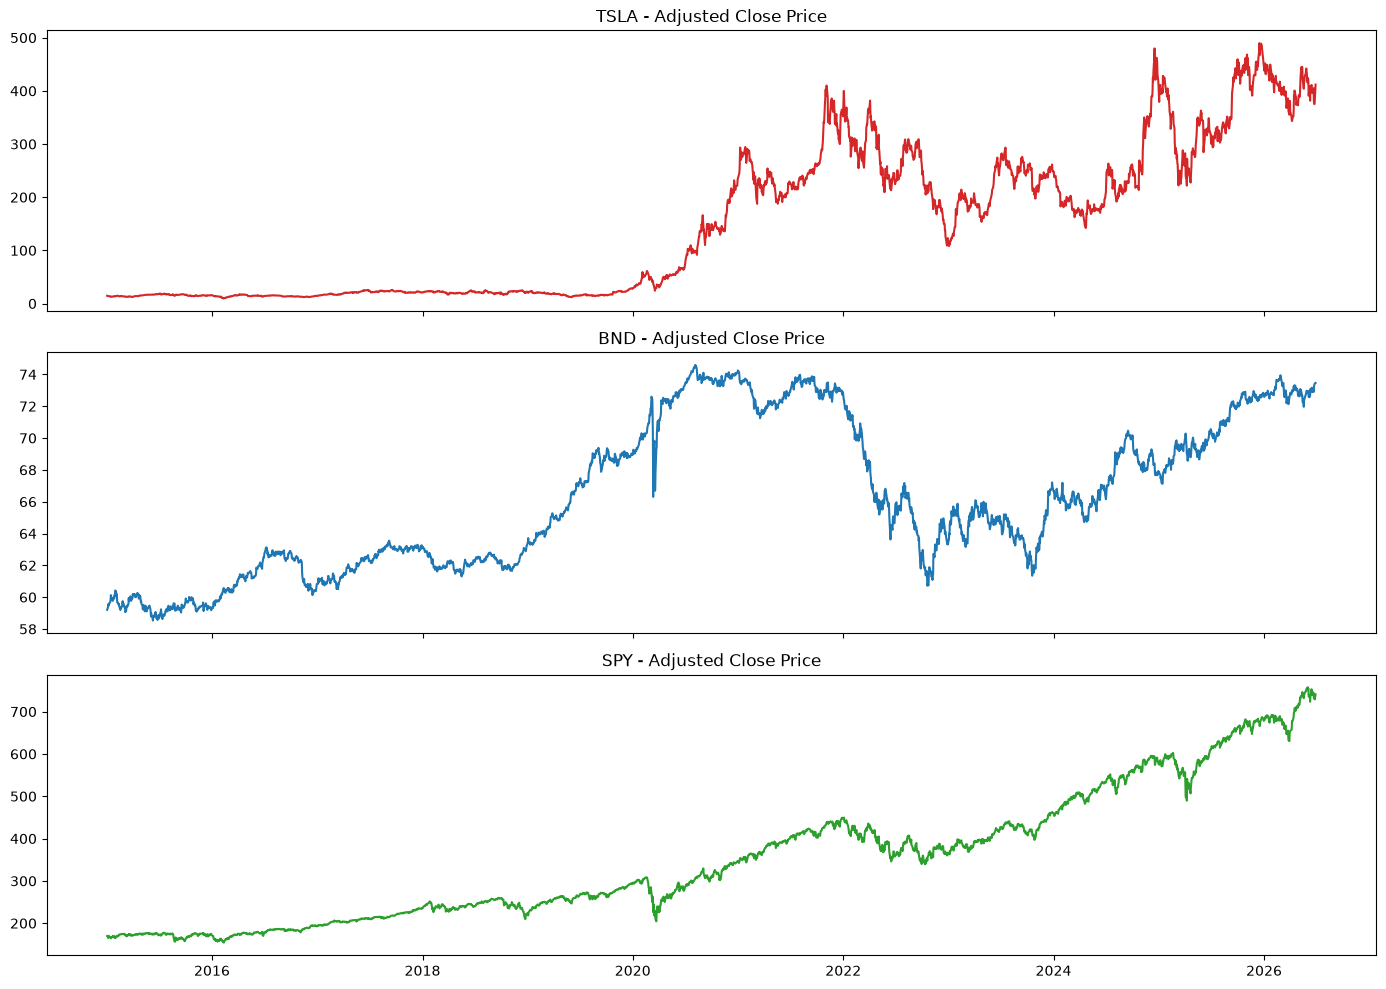

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(tsla.index, tsla["Adj Close"], color="tab:red")
axes[0].set_title("TSLA - Adjusted Close Price")
axes[1].plot(bnd.index, bnd["Adj Close"], color="tab:blue")
axes[1].set_title("BND - Adjusted Close Price")
axes[2].plot(spy.index, spy["Adj Close"], color="tab:green")
axes[2].set_title("SPY - Adjusted Close Price")
plt.tight_layout()
plt.show()

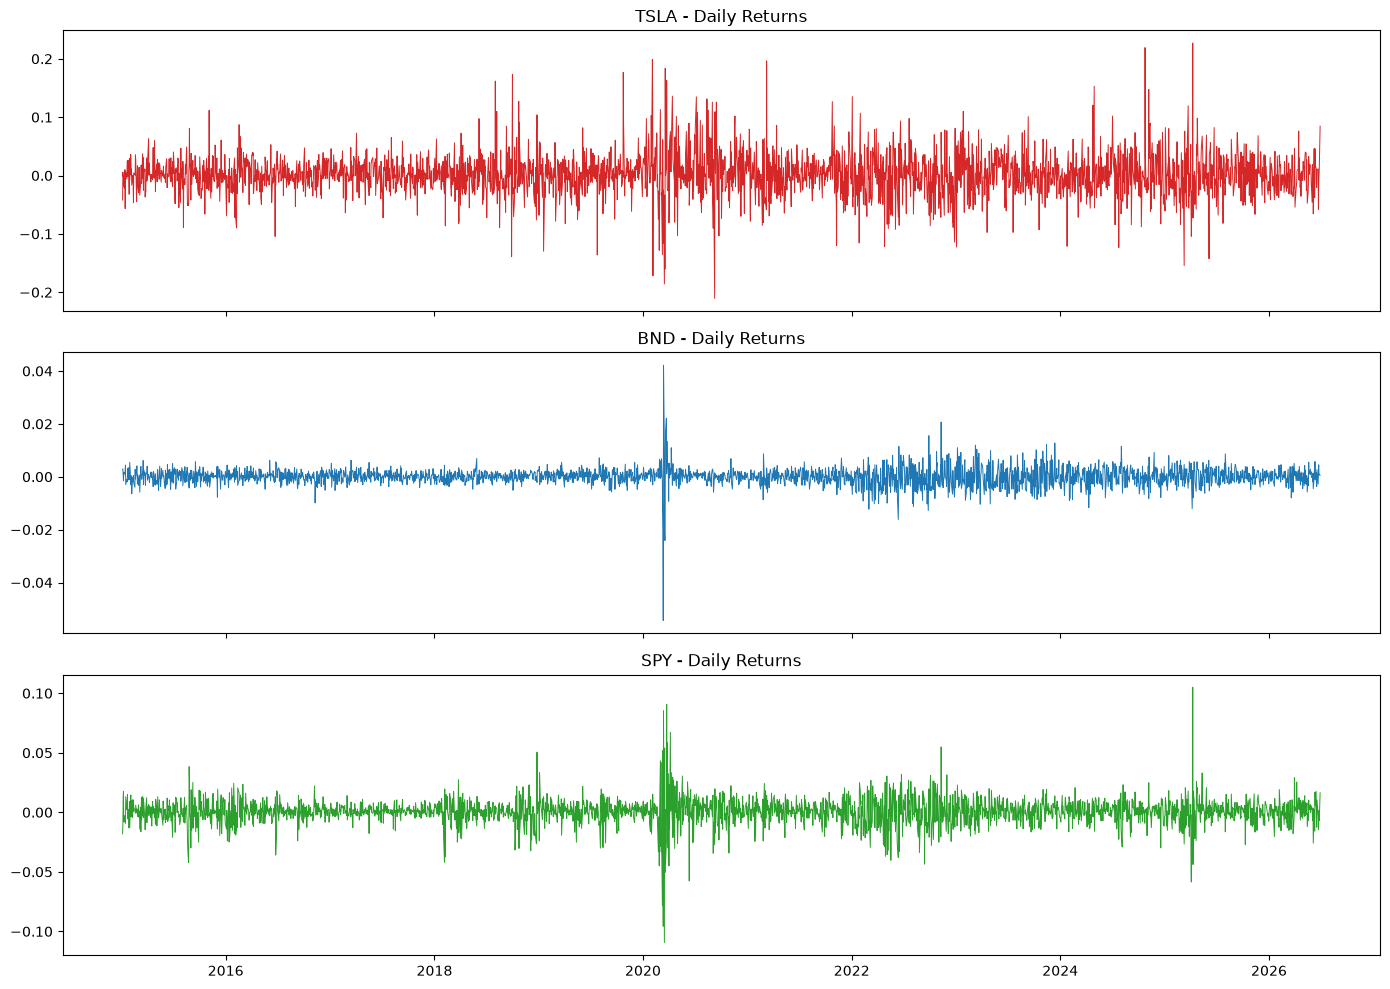

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(tsla.index, tsla["Daily Return"], color="tab:red", linewidth=0.7)
axes[0].set_title("TSLA - Daily Returns")
axes[1].plot(bnd.index, bnd["Daily Return"], color="tab:blue", linewidth=0.7)
axes[1].set_title("BND - Daily Returns")
axes[2].plot(spy.index, spy["Daily Return"], color="tab:green", linewidth=0.7)
axes[2].set_title("SPY - Daily Returns")
plt.tight_layout()
plt.show()

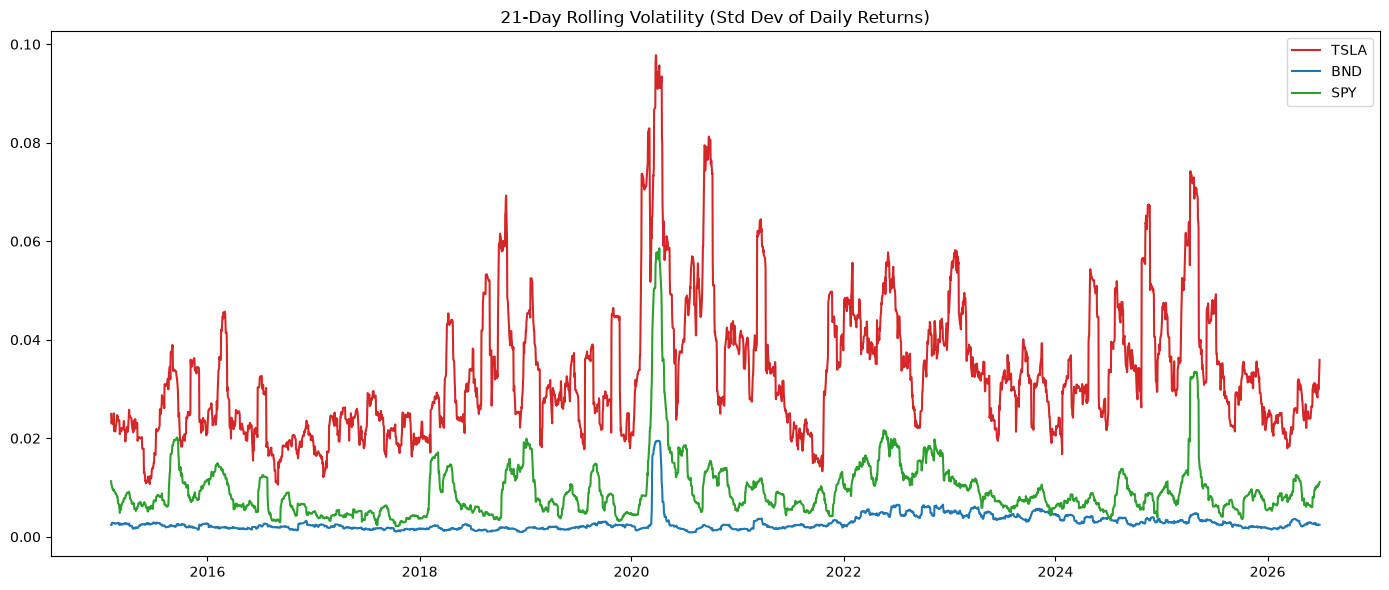

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(tsla.index, tsla["Rolling Volatility"], color="tab:red", label="TSLA")
ax.plot(bnd.index, bnd["Rolling Volatility"], color="tab:blue", label="BND")
ax.plot(spy.index, spy["Rolling Volatility"], color="tab:green", label="SPY")
ax.set_title("21-Day Rolling Volatility (Std Dev of Daily Returns)")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
outliers_tsla = get_outliers(tsla)
outliers_bnd = get_outliers(bnd)
outliers_spy = get_outliers(spy)
print(f"TSLA: {len(outliers_tsla)} outliers")
print(outliers_tsla.head())

adf_results = [
    adf_test(tsla["Adj Close"], "TSLA - Close Price"),
    adf_test(tsla["Daily Return"], "TSLA - Daily Return"),
    adf_test(spy["Adj Close"], "SPY - Close Price"),
    adf_test(spy["Daily Return"], "SPY - Daily Return"),
    adf_test(bnd["Adj Close"], "BND - Close Price"),
    adf_test(bnd["Daily Return"], "BND - Daily Return"),
]
for r in adf_results:
    print(f"{r['name']}: p={r['p_value']:.4f} → {'Stationary' if r['stationary'] else 'Non-Stationary'}")

TSLA: 46 outliers
Price       Daily Return
Date                    
2020-09-08     -0.210628
2020-03-16     -0.185778
2020-02-05     -0.171758
2020-03-18     -0.160344
2025-03-10     -0.154262
TSLA - Close Price: p=0.7270 → Non-Stationary
TSLA - Daily Return: p=0.0000 → Stationary
SPY - Close Price: p=0.9967 → Non-Stationary
SPY - Daily Return: p=0.0000 → Stationary
BND - Close Price: p=0.7354 → Non-Stationary
BND - Daily Return: p=0.0000 → Stationary


In [19]:
for name, df in [("TSLA", tsla), ("BND", bnd), ("SPY", spy)]:
    metrics = risk_metrics(df)
    print(f"\n{name}")
    print(f"VaR (95%): {metrics['var_95']:.4f}")
    print(f"Annual Return: {metrics['annual_return']*100:.2f}%")
    print(f"Annual Volatility: {metrics['annual_volatility']*100:.2f}%")
    print(f"Sharpe Ratio: {metrics['sharpe_ratio']:.3f}")


TSLA
VaR (95%): -0.0517
Annual Return: 45.42%
Annual Volatility: 57.18%
Sharpe Ratio: 0.724

BND
VaR (95%): -0.0048
Annual Return: 2.03%
Annual Volatility: 5.31%
Sharpe Ratio: -0.372

SPY
VaR (95%): -0.0167
Annual Return: 14.43%
Annual Volatility: 17.65%
Sharpe Ratio: 0.591


In [20]:
import os
os.listdir("../data/processed")

['bnd.csv', 'spy.csv', 'tsla.csv']